In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from pathlib import Path
import sys

from mujoco_irb120.common.helper_fns import *
# import mujoco_irb120.common.helper_fns as helpers

/home/hylander2126/Documents/github/mujoco_irb120/src/mujoco_irb120/common/plotting_helper.py:17: SyntaxWarning: invalid escape sequence '\c'
  x_label: str = "Tipping angle ||$^\circ$||",
/home/hylander2126/Documents/github/mujoco_irb120/src/mujoco_irb120/common/plotting_helper.py:154: SyntaxWarning: invalid escape sequence '\c'
  ax2.set_ylabel("Tipping angle ($^\circ$)", color="black")


## Formulating New 'Squash and Pull' Tipping Paradigm

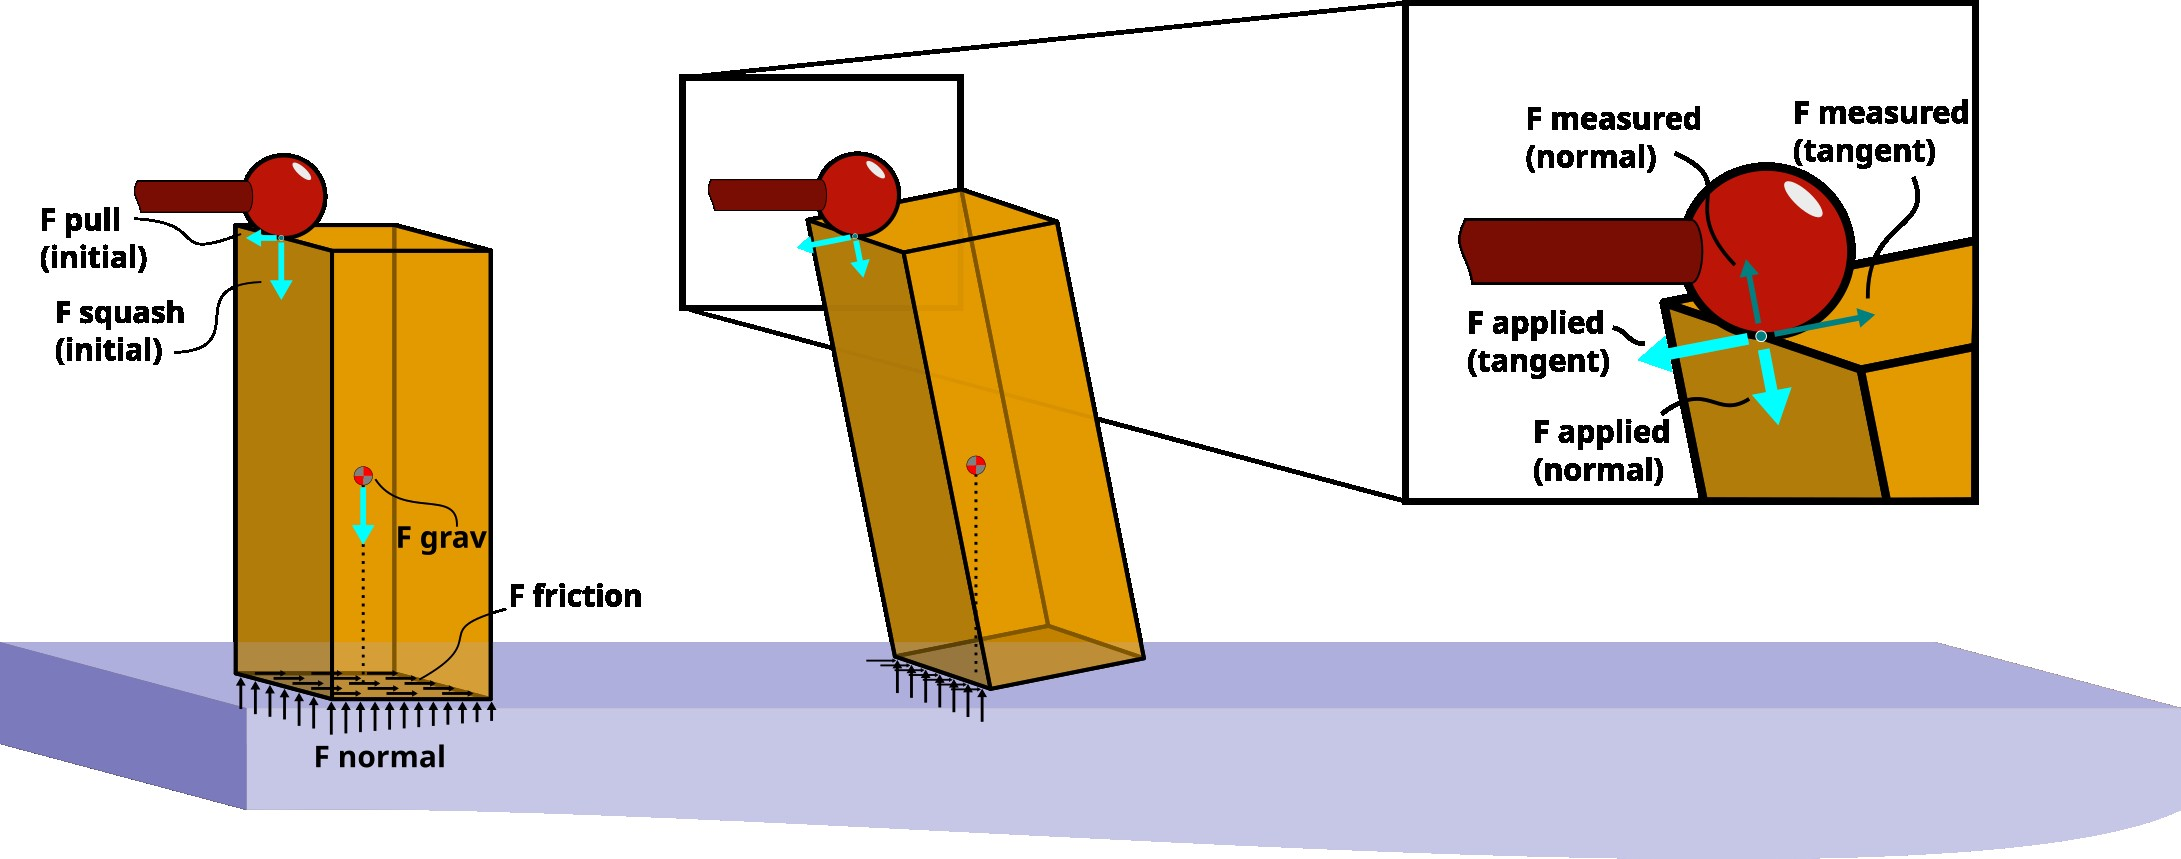

Given the above image, we can write the Force and Moment balance equations under a quasistatic regime.

$$
F_\text{applied} + F_\text{grav}+F_\text{fric}+F_\text{normal} = 0
$$

$$
(p_\text{finger}\times F_\text{applied}) + (p_\text{c}\times F_\text{grav}) + (p_\text{fric}\times F_\text{fric}) + (p_\text{normal}\times F_\text{normal})= 0
$$

For *Object Frame* $\{O\}$ located at tipping edge, we can say:
$$
\cancel{p_\text{fric}}\,0 \qquad \cancel{p_\text{normal}\,0}
$$


### Transforming measured wrenches to body wrenches
Of course, our F/T sensor is mounted 'behind' the finger. So to satisfy the wrench balance, we must perform the **adjoint transformation**.
Given: $\{O\} \,, \{B\} \,, \{S\}$ Object, (robot) Base, and Sensor frames, respectively:

$$
w^O_\text{app} = Ad_{T_{o/s}} \, w^S_\text{meas}
$$

$$
\begin{bmatrix}
f^O_\text{app} \\ \tau^O_\text{app}
\end{bmatrix} 
=
\begin{bmatrix}
R^O_S & 0 \\ \left[p^O_{s/o}\right]_\times R^O_S & R^O_S
\end{bmatrix}
\,
\begin{bmatrix}
f^S_\text{meas} \\ \tau^S_\text{meas}
\end{bmatrix}
$$
where:
- $R^O_S$ is rotation from Sensor to Object frame.
- $p^O_{s/o}$ is translation vector from Pivot to Sensor origin in the Object frame.
- $\left[\cdot\right]_\times$ is the skew-symmetric matrix, recall equivalent to cross product.


## Equations of (quasistatic) motion:
$$
w^O_\text{applied} + w^O_\text{gravity} + w^O_\text{ground} = 0
$$
Decomposed with frames: $O$ object, $S$ sensor, & $B$ robot base:
$$
^O\mathbf{w}_{app} = \begin{bmatrix} ^O\mathbf{R}_S & \mathbf{0} \\ [^O\mathbf{p}_{s/o}]_\times ^O\mathbf{R}_S & ^O\mathbf{R}_S \end{bmatrix} \begin{bmatrix} ^S\mathbf{f}_{meas} \\ ^S\tau_{meas} \end{bmatrix}
$$
$$
^O\mathbf{w}_{grav} = \begin{bmatrix} ^O\mathbf{f}_{grav} \\ ^S\tau_{grav} \end{bmatrix}
=
\begin{bmatrix} m  ^O\mathbf{g}(\theta) \\ ^O\mathbf{p}_{com} \times (m  ^O\mathbf{g}(\theta)) \end{bmatrix}
$$
$$
^O\mathbf{w}_{ground} = \begin{bmatrix} ^O\mathbf{f}_{ground} \\ 0_{3\times 1} \end{bmatrix}
=
\begin{bmatrix} 
\mathbf{f}_{t,x} \\ \mathbf{f}_{t,y} \\ \mathbf{N}_t \\ 0_{3\times 1}
\end{bmatrix}
$$
So we have 6 Equations, 3 from $F$ and 3 from $\tau$
And we have 6 unknowns, $\{m\,, x_c\,, y_c\,, z_c\,, \mu_f \text{(finger)}\,, \mu_t \text{(table)} \}$

Take the 6 unknowns as our parameter vector: $x = \left[m, x_c, y_c, z_c, \mu_f, \mu_t \right]$
1. Solve for CoM and mass with least squares, as usual
2. Solve for friction using **limit of stability** approximation (since no sliding)
$$
\begin{matrix}
\mu_f \approx \frac{||\text{proj}_{tan}(^o\mathbf{f}_{app})||}{\text{proj}_{norm}(^o\mathbf{f}_{app})} &&&&& \mu_t \approx \frac{\sqrt{f^2_{tx}+f^2_{ty}}}{N_t}
\end{matrix}
$$

# Test out fwd and bkwd models

In [2]:
from copy import deepcopy
from scipy.optimize import curve_fit
from mujoco_irb120.common.com_estimation import model_fwd_wrench
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#### First, basic fwd model with synthetic values for box object

In [ ]:
# Generate some synthetic data with known parameters to test fitting procedure
mass = 0.615
com = np.array([0.05, 0.00, 0.15])
mu = 0.1

N_data = 3
max_angle = -np.deg2rad(30)
angles = np.zeros([N_data, 3])
angles[:, 1] = np.linspace(0, max_angle, N_data)

# print(f"Angles tested:\n {np.rad2deg(angles[:,1])}")

w_grav_fwd, w_ground_fwd = model_fwd_wrench(angles, com, mass, mu) #, rob_vel_B=rob_vels)
w_app_required = w_grav_fwd + w_ground_fwd

debug = True

if debug:
    for i in range(N_data):
        ang = np.rad2deg(angles[i, 1]).round(2)
        print(f"\n{i}: Residuals for synthetic datapoint {ang}:")
        print(f"Gravity Wrench:\n {w_grav_fwd[i]}")
        print(f"Ground Reaction Wrench:\n {w_ground_fwd[i]}")
        print(f"Applied wrench must be:\n {w_app_required[i]}")



0: Residuals for synthetic datapoint 0.0:
Gravity Wrench:
 [ 0.         0.        -6.03315   -0.         0.3016575  0.       ]
Ground Reaction Wrench:
 [0.      0.      6.03315 0.      0.      0.     ]
Applied wrench must be:
 [0.        0.        0.        0.        0.3016575 0.       ]

1: Residuals for synthetic datapoint -15.0:
Gravity Wrench:
 [-1.56149412  0.         -5.8275754  -0.          0.05715465  0.        ]
Ground Reaction Wrench:
 [1.56149412 0.         5.8275754  0.         0.         0.        ]
Applied wrench must be:
 [0.         0.         0.         0.         0.05715465 0.        ]

2: Residuals for synthetic datapoint -30.0:
Gravity Wrench:
 [-3.016575    0.         -5.22486116 -0.         -0.19124319  0.        ]
Ground Reaction Wrench:
 [3.016575   0.         5.22486116 0.         0.         0.        ]
Applied wrench must be:
 [ 0.          0.          0.          0.         -0.19124319  0.        ]


#### The basic (torque) curve fit would look like this

In [22]:
# Borrow the "pseudo-data" from the forward model to test the fitting procedure. In practice, this would be replaced with real sensor data.
w_app_pred = deepcopy(w_app_required)

# Initial guesses for parameters
com_guess = 1.0 #np.array([0.04, 0.01, 0.14])
mass_guess = 0.01
mu_guess = 0.05
f_normal_guess = mass_guess * 9.81

# Define a TORQUE wrapper function for curve_fit that only fits on the torque components (like previous work)
def model_wrapper_torque(angles_flat, com_z, mass):
    angles_reshaped = angles_flat.reshape(-1, 3)
    com = np.array([0.05, 0.0, com_z])
    mu = 0.1

    w_grav_pred, _ = model_fwd_wrench(angles_reshaped, com, mass, mu)
    return w_grav_pred.flatten()

# Flatten the angles and w_app for curve_fit
angles_flat = angles.flatten()
w_app_flat = w_app_pred.flatten()

# Initial guess for parameters
initial_guess = [com_guess, mass_guess]
initial_bounds = ([0.0, 1e-6], [1e6, 1e6])  # Bounds for com_z and mass
# Fit the model to the data
popt, _ = curve_fit(model_wrapper_torque, angles_flat, w_app_flat, p0=initial_guess, bounds=initial_bounds)

print(f"Estimated parameters from curve_fit: com_z = {popt[0]:.4f} m, mass = {popt[1]:.4f} kg")

[[ 0.          0.         -0.0981    ]
 [-0.02539015  0.         -0.09475732]
 [-0.04905     0.         -0.08495709]]
[[ 0.          0.         -0.0981    ]
 [-0.02539015  0.         -0.09475732]
 [-0.04905     0.         -0.08495709]]
[[ 0.          0.         -0.09810015]
 [-0.02539019  0.         -0.09475746]
 [-0.04905007  0.         -0.08495722]]
[[ 0.          0.         -0.04632665]
 [-0.01199022  0.         -0.0447481 ]
 [-0.02316332  0.         -0.04012005]]
[[ 0.          0.         -0.04632665]
 [-0.01199022  0.         -0.0447481 ]
 [-0.02316332  0.         -0.04012005]]
[[ 0.          0.         -0.04632679]
 [-0.01199026  0.         -0.04474824]
 [-0.0231634   0.         -0.04012018]]
[[ 0.          0.         -0.00906111]
 [-0.00234519  0.         -0.00875236]
 [-0.00453056  0.         -0.00784715]]
[[ 0.          0.         -0.03719776]
 [-0.00962749  0.         -0.03593028]
 [-0.01859888  0.         -0.03221421]]
[[ 0.          0.         -0.03719776]
 [-0.00962749  0.

#### Now we do two passes, one to cancel gravity, and one to get friction

In [ ]:
# Generate some synthetic data with known parameters to test fitting procedure
mass = 0.615
com = np.array([0.05, 0.00, 0.15])
mu = 0.1

N_data = 30
max_angle = -np.deg2rad(30)
angles = np.zeros([N_data, 3])
angles[:, 1] = np.linspace(0, max_angle, N_data)

rob_vels = np.tile(np.array([-1.0, 0.0, 0.0]), (angles.shape[0], 1))
rob_vels[0, :] = np.zeros(3)


w_grav_fwd, w_ground_fwd = model_fwd_wrench(angles, com, mass, mu) #, rob_vel_B=rob_vels)
w_app_required = w_grav_fwd #+ w_ground_fwd

debug = False

if debug:
    for i in range(N_data):
        ang = np.rad2deg(angles[i, 1]).round(2)
        print(f"\n{i}: Residuals for synthetic datapoint {ang}:")
        print(f"Gravity Wrench:\n {w_app_required[i]}")
        print(f"Ground Reaction Wrench:\n {w_ground_fwd[i]}")
        print(f"Applied wrench must be:\n {w_app_required[i]}")

# Now that we have an 'initial' gravity wrench, let's pass that into the fwd model to
# get a more accurate estimate of the ground reaction wrench, and see how that 
# compares to the 'true' ground reaction wrench from the original fwd model.
if debug: print("\n*******************************************************")
w_app_pred = deepcopy(w_app_required)

w_grav_synth, w_ground_synth = model_fwd_wrench(angles, com, mass, mu, w_O_app=w_app_pred, rob_vel_B=rob_vels)
w_app_synth = w_grav_synth + w_ground_synth

# Compare the 'true' applied wrench to the one synthesized from the fwd model with the 'true' gravity wrench as input.
if debug:
    for i in range(N_data):
        ang = np.rad2deg(angles[i, 1]).round(2)
        print(f"\n{i}: Residuals for synthetic datapoint {ang} with fwd model synthesized applied wrench:")
        print(f"Gravity Wrench:\n {w_grav_synth[i]}")
        print(f"Ground Reaction Wrench:\n {w_ground_synth[i]}")
    print(f"Applied wrench required to achieve this gravity wrench and ground reaction wrench:\n {w_app_synth[i]}")


[[ 0.          0.         -6.03315   ]
 [-0.10892339  0.         -6.03216666]
 [-0.21781127  0.         -6.02921696]
 [-0.32662816  0.         -6.02430187]
 [-0.43533856  0.         -6.01742297]
 [-0.54390706  0.         -6.00858253]
 [-0.65229826  0.         -5.99778342]
 [-0.76047682  0.         -5.98502915]
 [-0.86840748  0.         -5.97032389]
 [-0.97605505  0.         -5.95367243]
 [-1.08338446  0.         -5.93508021]
 [-1.1903607   0.         -5.91455327]
 [-1.29694891  0.         -5.89209831]
 [-1.40311434  0.         -5.86772265]
 [-1.50882239  0.         -5.84143423]
 [-1.6140386   0.         -5.81324164]
 [-1.71872866  0.         -5.78315405]
 [-1.82285845  0.         -5.75118127]
 [-1.92639403  0.         -5.71733373]
 [-2.02930164  0.         -5.68162246]
 [-2.13154775  0.         -5.6440591 ]
 [-2.23309901  0.         -5.6046559 ]
 [-2.33392233  0.         -5.56342569]
 [-2.43398485  0.         -5.52038193]
 [-2.53325393  0.         -5.47553864]
 [-2.63169723  0.        

#### Now let's try fitting some parameters using the output from the fwd model

In [ ]:
# Initial guesses for parameters
com_guess = 1.0 #np.array([0.04, 0.01, 0.14])
mass_guess = 0.01
mu_guess = 0.05
f_normal_guess = mass_guess * 9.81

# Define a TORQUE wrapper function for curve_fit that only fits on the torque components (like previous work)
def model_wrapper(angles_flat, com_z, mass, mu):
    angles_reshaped = angles_flat.reshape(-1, 3)
    com = np.array([0.05, 0.0, com_z])
    rob_vels = np.tile(np.array([-1.0, 0.0, 0.0]), (angles_reshaped.shape[0], 1))
    rob_vels[0, :] = np.zeros(3)

    w_grav_pred, _ = model_fwd_wrench(angles_reshaped, com, mass, mu)
    w_app_pred = deepcopy(w_grav_pred)

    w_grav_fwd, w_ground_fwd = model_fwd_wrench(angles_reshaped, com, mass, mu, w_O_app=w_app_pred, rob_vel_B=rob_vels)
    w_app_fwd = w_grav_fwd + w_ground_fwd
    return -w_app_fwd.flatten()

# Flatten the angles and w_app for curve_fit
angles_flat = angles.flatten()
w_app_flat = w_app_pred.flatten()

# Initial guess for parameters
initial_guess = [com_guess, mass_guess, mu_guess]
initial_bounds = ([0.0, 1e-6, 0.0], [1e6, 1e6, 10])  # Bounds for com_z, mass, and mu
# Fit the model to the data
popt, _ = curve_fit(model_wrapper, angles_flat, w_app_flat, p0=initial_guess, bounds=initial_bounds)

print(f"Estimated parameters from curve_fit: com_z = {popt[0]:.4f} m, mass = {popt[1]:.4f} kg, mu = {popt[2]:.4f}")

[[ 0.          0.         -0.0981    ]
 [-0.00177111  0.         -0.09808401]
 [-0.00354165  0.         -0.09803605]
 [-0.00531103  0.         -0.09795613]
 [-0.00707868  0.         -0.09784428]
 [-0.00884402  0.         -0.09770053]
 [-0.01060648  0.         -0.09752493]
 [-0.01236548  0.         -0.09731755]
 [-0.01412045  0.         -0.09707844]
 [-0.01587081  0.         -0.09680768]
 [-0.01761601  0.         -0.09650537]
 [-0.01935546  0.         -0.0961716 ]
 [-0.0210886   0.         -0.09580648]
 [-0.02281487  0.         -0.09541012]
 [-0.0245337   0.         -0.09498267]
 [-0.02624453  0.         -0.09452425]
 [-0.02794681  0.         -0.09403503]
 [-0.02963997  0.         -0.09351514]
 [-0.03132348  0.         -0.09296478]
 [-0.03299677  0.         -0.09238411]
 [-0.03465931  0.         -0.09177332]
 [-0.03631055  0.         -0.09113262]
 [-0.03794996  0.         -0.09046221]
 [-0.03957699  0.         -0.08976231]
 [-0.04119112  0.         -0.08903315]
 [-0.04279182  0.        

#### Visualize 'required' f_app across all object angles

[[ 0.          0.         -6.03315   ]
 [-0.07624849  0.         -6.03266816]
 [-0.15248479  0.         -6.0312227 ]
 [-0.22869674  0.         -6.02881387]
 [-0.30487216  0.         -6.02544205]
 [-0.38099889  0.         -6.02110777]
 [-0.45706475  0.         -6.01581173]
 [-0.53305761  0.         -6.00955477]
 [-0.60896532  0.         -6.00233789]
 [-0.68477576  0.         -5.99416225]
 [-0.76047682  0.         -5.98502915]
 [-0.8360564   0.         -5.97494005]
 [-0.91150244  0.         -5.96389656]
 [-0.98680289  0.         -5.95190045]
 [-1.06194571  0.         -5.93895363]
 [-1.13691891  0.         -5.92505817]
 [-1.2117105   0.         -5.91021629]
 [-1.28630854  0.         -5.89443036]
 [-1.36070112  0.         -5.8777029 ]
 [-1.43487636  0.         -5.86003658]
 [-1.50882239  0.         -5.84143423]
 [-1.58252742  0.         -5.82189882]
 [-1.65597967  0.         -5.80143346]
 [-1.72916741  0.         -5.78004144]
 [-1.80207894  0.         -5.75772615]
 [-1.87470263  0.        

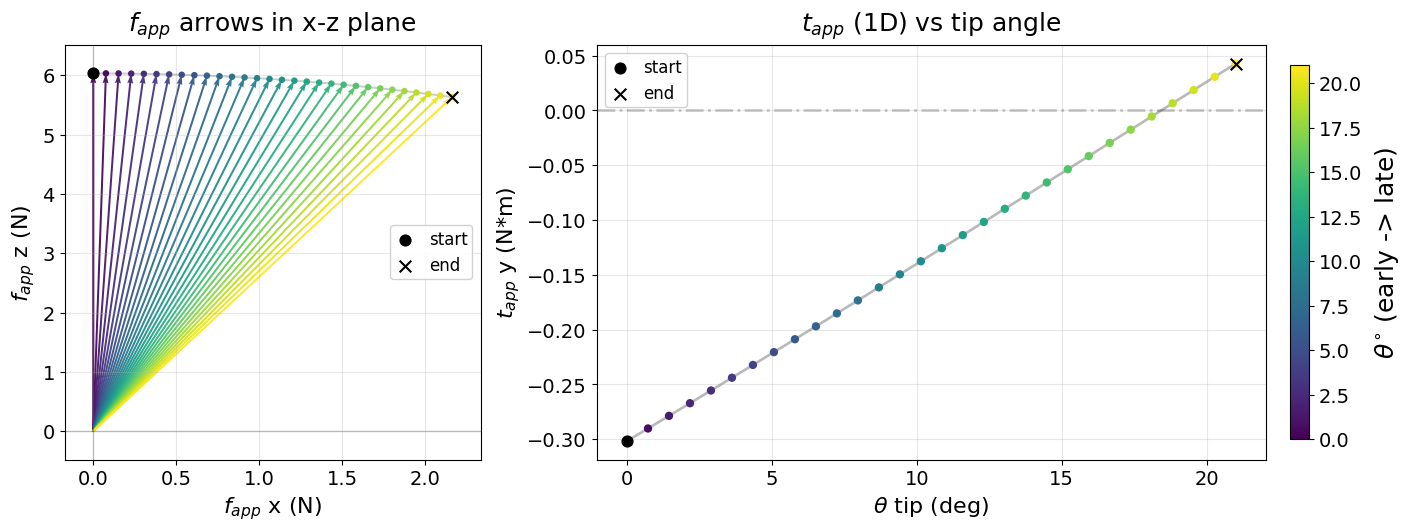

In [25]:
# --- 2D arrows over time for force + 1D line plot for torque (formatted) ---
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Create a dense angle sweep.
mass = 0.615
com = np.array([0.05, 0.00, 0.15])
mu = 0.1

N_plot = 30
max_angle = -np.deg2rad(21)
angles_plot = np.zeros([N_plot, 3])
angles_plot[:, 1] = np.linspace(0, max_angle, N_plot)

rob_vels = np.tile(np.array([-1.0, 0.0, 0.0]), (angles_plot.shape[0], 1))
rob_vels[0, :] = np.zeros(3)

# New model_fwd_wrench returns (w_grav, w_ground).
w_grav_plot, w_ground_plot = model_fwd_wrench(angles_plot, com, mass, mu)
w_plot = -w_grav_plot # + w_ground_plot

# Ensure (N,6) shape
w_plot = np.asarray(w_plot).reshape(-1, 6)
theta_tip = -angles_plot[:, 1]

# Use x-z components for 2D force arrows
f_x = w_plot[:, 0]
f_z = w_plot[:, 2]

# Torque is treated as 1D along y for plotting
t_y = w_plot[:, 4]

# Color by progression (time-like tipping index)
progress = np.linspace(0.0, 1.0, len(theta_tip))
cmap = cm.viridis

fig, axes = plt.subplots(
    1, 2,
    figsize=(14.0, 5.2),
    constrained_layout=True,
    gridspec_kw={'width_ratios': [1.15, 1.85]}
)

title_fs = 18
label_fs = 16
tick_fs = 14
legend_fs = 12

# ------------------------------------------------------------------
# Left: force vectors in standard 2D Cartesian plot (x-z plane)
# ------------------------------------------------------------------
n = len(f_x)
x0 = np.zeros(n)
z0 = np.zeros(n)

axes[0].quiver(
    x0, z0, f_x, f_z, progress, cmap=cmap,
    angles='xy', scale_units='xy', scale=1.0, width=0.0048, alpha=0.95
)
axes[0].plot(f_x, f_z, color='gray', alpha=0.40, linewidth=1.4)
axes[0].scatter(f_x, f_z, c=progress, cmap=cmap, s=22, edgecolors='none', zorder=3)
axes[0].scatter(f_x[0], f_z[0], c='black', s=60, marker='o', label='start', zorder=4)
axes[0].scatter(f_x[-1], f_z[-1], c='black', s=70, marker='x', label='end', zorder=4)
axes[0].axhline(0.0, color='k', alpha=0.20, linewidth=1.0)
axes[0].axvline(0.0, color='k', alpha=0.20, linewidth=1.0)

# Add independent margins to avoid the plot looking compressed.
x_min, x_max = np.min(np.r_[f_x, 0.0]), np.max(np.r_[f_x, 0.0])
z_min, z_max = np.min(np.r_[f_z, 0.0]), np.max(np.r_[f_z, 0.0])
x_span = max(x_max - x_min, 1e-3)
z_span = max(z_max - z_min, 1e-3)
axes[0].set_xlim(x_min - 0.08 * x_span, x_max + 0.08 * x_span)
axes[0].set_ylim(z_min - 0.08 * z_span, z_max + 0.08 * z_span)

axes[0].set_xlabel('$f_{app}$ x (N)', fontsize=label_fs)
axes[0].set_ylabel('$f_{app}$ z (N)', fontsize=label_fs)
axes[0].set_title('$f_{app}$ arrows in x-z plane', fontsize=title_fs, pad=10)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(labelsize=tick_fs)
axes[0].legend(loc='best', fontsize=legend_fs, framealpha=0.9, handlelength=1.2, borderpad=0.3)

# ------------------------------------------------------------------
# Right: 1D torque line plot over angle/time
# ------------------------------------------------------------------
theta_deg = np.rad2deg(theta_tip)
axes[1].plot(theta_deg, t_y, color='gray', alpha=0.55, linewidth=1.9)
axes[1].scatter(theta_deg, t_y, c=progress, cmap=cmap, s=36, edgecolors='none', zorder=3)
axes[1].scatter(theta_deg[0], t_y[0], c='black', s=60, marker='o', label='start', zorder=4)
axes[1].scatter(theta_deg[-1], t_y[-1], c='black', s=70, marker='x', label='end', zorder=4)
axes[1].axhline(0.0, color='k', alpha=0.20, linestyle='-.', linewidth=2.0)
axes[1].set_xlabel('$\\theta$ tip (deg)', fontsize=label_fs)
axes[1].set_ylabel('$t_{app}$ y (N*m)', fontsize=label_fs)
axes[1].set_title('$t_{app}$ (1D) vs tip angle', fontsize=title_fs, pad=10)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(labelsize=tick_fs)
axes[1].legend(loc='best', fontsize=legend_fs, framealpha=0.9, handlelength=1.2, borderpad=0.3)

# Shared colorbar for progression
sm = ScalarMappable(norm=Normalize(vmin=0.0, vmax=np.max(theta_deg)), cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, location='right', shrink=0.90, pad=0.02)
cbar.set_label('$\\theta ^{\\circ}$ (early -> late)', fontsize=18, labelpad=8)
cbar.ax.tick_params(labelsize=tick_fs)

plt.show()

### 'Sweep' across different values for com, mass, and mu and visualize

In [28]:
# --- One-at-a-time parameter sweeps around fixed defaults ---

# Defaults (held fixed unless actively swept)
mu_default = 0.3
mass_default = 0.6          # kg
com_z_default = 0.12        # m
com_xy_default = np.array([0.05, 0.00])

# Sweep ranges
mu_values = np.array([0.1, 0.2, 0.3, 0.5, 0.7])
mass_values = np.array([0.2, 0.4, 0.6, 0.8, 1.0])
com_z_values = np.array([0.08, 0.10, 0.12, 0.15, 0.18])

# Shared setup
N_data = 1
angles = np.zeros((N_data, 3))
angles[:, 1] = np.deg2rad(5)

# --- Sweep 1: vary mu only ---
mu_sweep = []
for mu in mu_values:
    com = np.array([com_xy_default[0], com_xy_default[1], com_z_default])
    w_grav, w_ground = model_fwd_wrench(angles, com, mass_default, mu)
    w_app_required = -w_grav # + w_ground
    mu_sweep.append({
        'mu': mu,
        'mass': mass_default,
        'com_z': com_z_default,
        'w_app_required_norm': np.linalg.norm(w_app_required),
        'w_app_required': w_app_required.flatten(),
    })

# --- Sweep 2: vary mass only ---
mass_sweep = []
for mass in mass_values:
    com = np.array([com_xy_default[0], com_xy_default[1], com_z_default])
    w_grav, w_ground = model_fwd_wrench(angles, com, mass, mu_default)
    w_app_required = -w_grav # + w_ground
    mass_sweep.append({
        'mu': mu_default,
        'mass': mass,
        'com_z': com_z_default,
        'w_app_required_norm': np.linalg.norm(w_app_required),
        'w_app_required': w_app_required.flatten(),
    })

# --- Sweep 3: vary com_z only ---
comz_sweep = []
for com_z in com_z_values:
    com = np.array([com_xy_default[0], com_xy_default[1], com_z])
    w_grav, w_ground = model_fwd_wrench(angles, com, mass_default, mu_default)
    w_app_required = -w_grav # + w_ground
    comz_sweep.append({
        'mu': mu_default,
        'mass': mass_default,
        'com_z': com_z,
        'w_app_required_norm': np.linalg.norm(w_app_required),
        'w_app_required': w_app_required.flatten(),
    })

df_mu = pd.DataFrame(mu_sweep)
df_mass = pd.DataFrame(mass_sweep)
df_comz = pd.DataFrame(comz_sweep)

def add_wrench_decomposition(df):
    # For N_data=1, each entry is a 6-vector [Fx,Fy,Fz,Tx,Ty,Tz].
    W = np.vstack(df['w_app_required'].to_numpy())
    df['f_app_x'] = W[:, 0]
    df['f_app_y'] = W[:, 1]
    df['f_app_z'] = W[:, 2]
    df['t_app_x'] = W[:, 3]
    df['t_app_y'] = W[:, 4]
    df['t_app_z'] = W[:, 5]
    df['f_app_required_norm'] = np.linalg.norm(W[:, :3], axis=1)
    df['t_app_required_norm'] = np.linalg.norm(W[:, 3:], axis=1)
    return df

df_mu = add_wrench_decomposition(df_mu)
df_mass = add_wrench_decomposition(df_mass)
df_comz = add_wrench_decomposition(df_comz)

print('Defaults used for one-at-a-time sweeps:')
print(f'  mu_default={mu_default}, mass_default={mass_default}, com_z_default={com_z_default}')
print(f'  points: mu={len(df_mu)}, mass={len(df_mass)}, com_z={len(df_comz)}')

[[ 0.5129987   0.         -5.86360199]]
[[ 0.5129987   0.         -5.86360199]]
[[ 0.5129987   0.         -5.86360199]]
[[ 0.5129987   0.         -5.86360199]]
[[ 0.5129987   0.         -5.86360199]]
[[ 0.17099957  0.         -1.954534  ]]
[[ 0.34199913  0.         -3.909068  ]]
[[ 0.5129987   0.         -5.86360199]]
[[ 0.68399827  0.         -7.81813599]]
[[ 0.85499784  0.         -9.77266999]]
[[ 0.5129987   0.         -5.86360199]]
[[ 0.5129987   0.         -5.86360199]]
[[ 0.5129987   0.         -5.86360199]]
[[ 0.5129987   0.         -5.86360199]]
[[ 0.5129987   0.         -5.86360199]]
Defaults used for one-at-a-time sweeps:
  mu_default=0.3, mass_default=0.6, com_z_default=0.12
  points: mu=5, mass=5, com_z=5


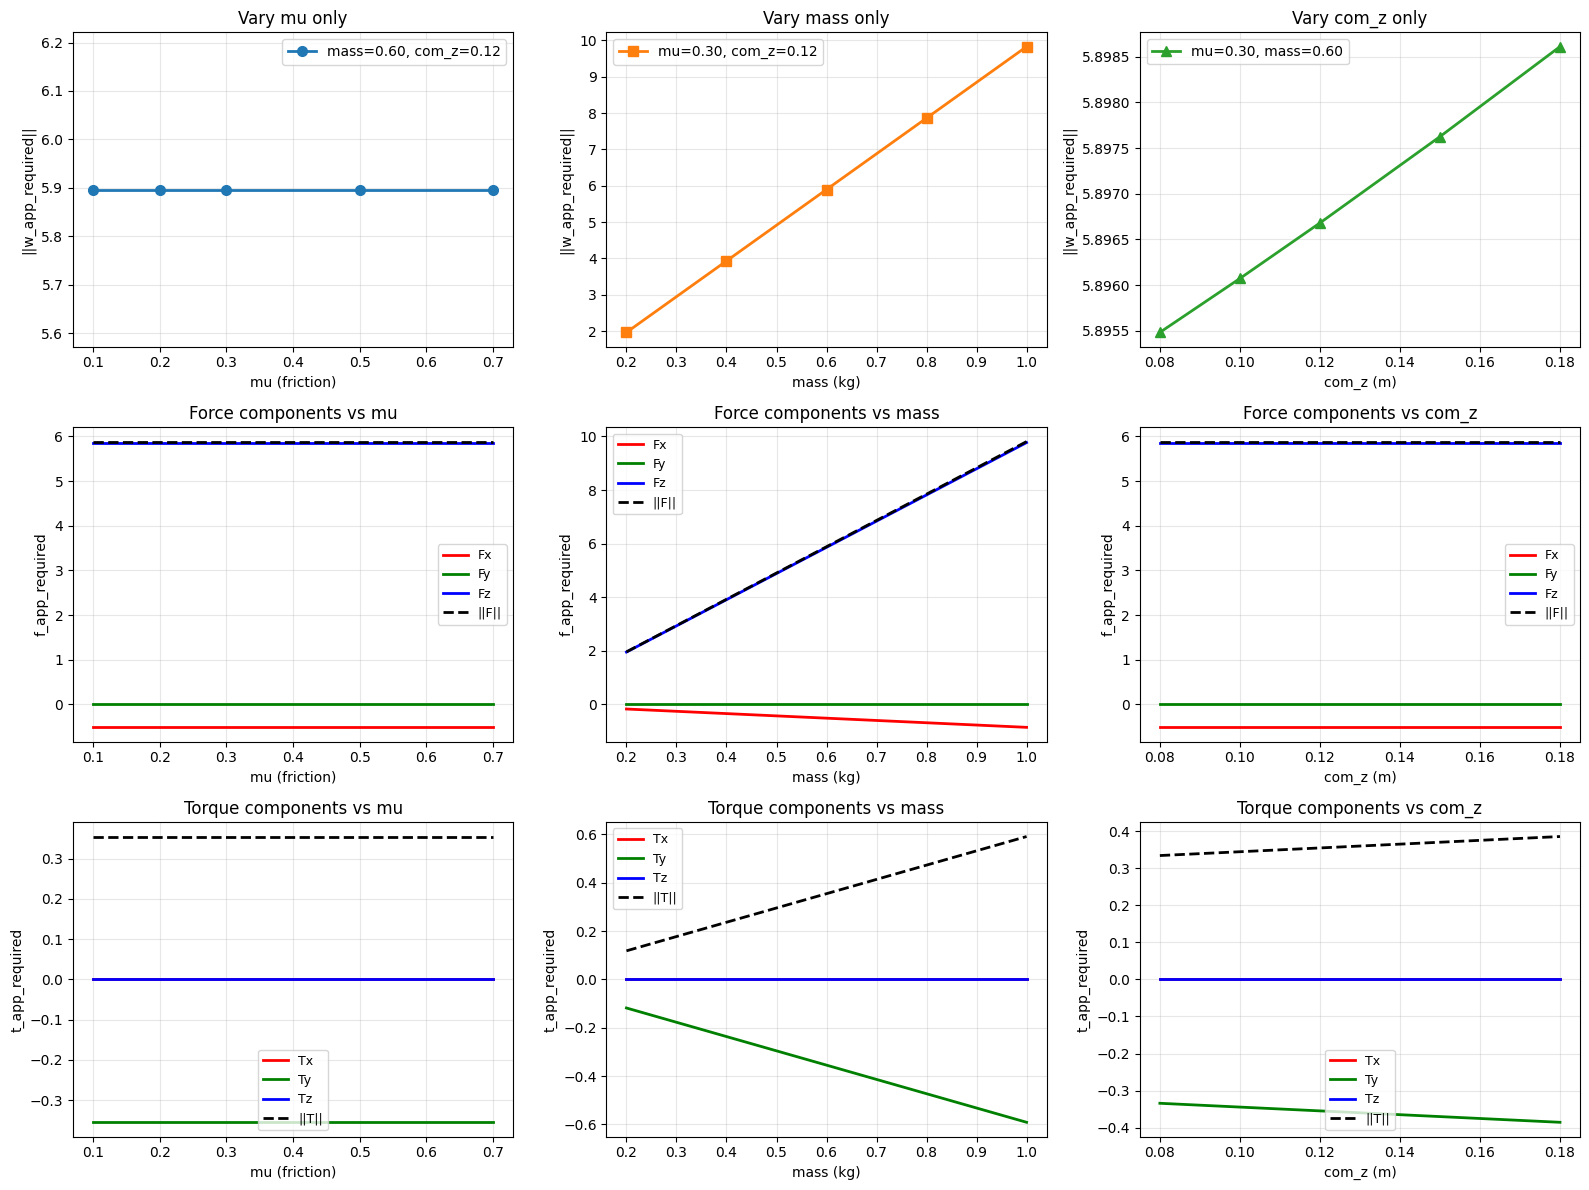

In [29]:
# --- Visualization: w_app_required + decomposed f_app_required and t_app_required ---

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

# ------------------------------------------------------------
# Row 1: total wrench magnitude ||w_app_required||
# ------------------------------------------------------------
axes[0, 0].plot(df_mu['mu'], df_mu['w_app_required_norm'], 'o-', lw=2, ms=7, color='tab:blue')
axes[0, 0].set_xlabel('mu (friction)')
axes[0, 0].set_ylabel('||w_app_required||')
axes[0, 0].set_title('Vary mu only')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend([f'mass={mass_default:.2f}, com_z={com_z_default:.2f}'], loc='best', fontsize=10)

axes[0, 1].plot(df_mass['mass'], df_mass['w_app_required_norm'], 's-', lw=2, ms=7, color='tab:orange')
axes[0, 1].set_xlabel('mass (kg)')
axes[0, 1].set_ylabel('||w_app_required||')
axes[0, 1].set_title('Vary mass only')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend([f'mu={mu_default:.2f}, com_z={com_z_default:.2f}'], loc='best', fontsize=10)

axes[0, 2].plot(df_comz['com_z'], df_comz['w_app_required_norm'], '^-', lw=2, ms=7, color='tab:green')
axes[0, 2].set_xlabel('com_z (m)')
axes[0, 2].set_ylabel('||w_app_required||')
axes[0, 2].set_title('Vary com_z only')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].legend([f'mu={mu_default:.2f}, mass={mass_default:.2f}'], loc='best', fontsize=10)

# ------------------------------------------------------------
# Row 2: force decomposition (Fx, Fy, Fz, and ||F||)
# ------------------------------------------------------------
axes[1, 0].plot(df_mu['mu'], df_mu['f_app_x'], 'r-', lw=2, label='Fx')
axes[1, 0].plot(df_mu['mu'], df_mu['f_app_y'], 'g-', lw=2, label='Fy')
axes[1, 0].plot(df_mu['mu'], df_mu['f_app_z'], 'b-', lw=2, label='Fz')
axes[1, 0].plot(df_mu['mu'], df_mu['f_app_required_norm'], 'k--', lw=2, label='||F||')
axes[1, 0].set_xlabel('mu (friction)')
axes[1, 0].set_ylabel('f_app_required')
axes[1, 0].set_title('Force components vs mu')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(loc='best', fontsize=9)

axes[1, 1].plot(df_mass['mass'], df_mass['f_app_x'], 'r-', lw=2, label='Fx')
axes[1, 1].plot(df_mass['mass'], df_mass['f_app_y'], 'g-', lw=2, label='Fy')
axes[1, 1].plot(df_mass['mass'], df_mass['f_app_z'], 'b-', lw=2, label='Fz')
axes[1, 1].plot(df_mass['mass'], df_mass['f_app_required_norm'], 'k--', lw=2, label='||F||')
axes[1, 1].set_xlabel('mass (kg)')
axes[1, 1].set_ylabel('f_app_required')
axes[1, 1].set_title('Force components vs mass')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(loc='best', fontsize=9)

axes[1, 2].plot(df_comz['com_z'], df_comz['f_app_x'], 'r-', lw=2, label='Fx')
axes[1, 2].plot(df_comz['com_z'], df_comz['f_app_y'], 'g-', lw=2, label='Fy')
axes[1, 2].plot(df_comz['com_z'], df_comz['f_app_z'], 'b-', lw=2, label='Fz')
axes[1, 2].plot(df_comz['com_z'], df_comz['f_app_required_norm'], 'k--', lw=2, label='||F||')
axes[1, 2].set_xlabel('com_z (m)')
axes[1, 2].set_ylabel('f_app_required')
axes[1, 2].set_title('Force components vs com_z')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].legend(loc='best', fontsize=9)

# ------------------------------------------------------------
# Row 3: torque decomposition (Tx, Ty, Tz, and ||T||)
# ------------------------------------------------------------
axes[2, 0].plot(df_mu['mu'], df_mu['t_app_x'], 'r-', lw=2, label='Tx')
axes[2, 0].plot(df_mu['mu'], df_mu['t_app_y'], 'g-', lw=2, label='Ty')
axes[2, 0].plot(df_mu['mu'], df_mu['t_app_z'], 'b-', lw=2, label='Tz')
axes[2, 0].plot(df_mu['mu'], df_mu['t_app_required_norm'], 'k--', lw=2, label='||T||')
axes[2, 0].set_xlabel('mu (friction)')
axes[2, 0].set_ylabel('t_app_required')
axes[2, 0].set_title('Torque components vs mu')
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].legend(loc='best', fontsize=9)

axes[2, 1].plot(df_mass['mass'], df_mass['t_app_x'], 'r-', lw=2, label='Tx')
axes[2, 1].plot(df_mass['mass'], df_mass['t_app_y'], 'g-', lw=2, label='Ty')
axes[2, 1].plot(df_mass['mass'], df_mass['t_app_z'], 'b-', lw=2, label='Tz')
axes[2, 1].plot(df_mass['mass'], df_mass['t_app_required_norm'], 'k--', lw=2, label='||T||')
axes[2, 1].set_xlabel('mass (kg)')
axes[2, 1].set_ylabel('t_app_required')
axes[2, 1].set_title('Torque components vs mass')
axes[2, 1].grid(True, alpha=0.3)
axes[2, 1].legend(loc='best', fontsize=9)

axes[2, 2].plot(df_comz['com_z'], df_comz['t_app_x'], 'r-', lw=2, label='Tx')
axes[2, 2].plot(df_comz['com_z'], df_comz['t_app_y'], 'g-', lw=2, label='Ty')
axes[2, 2].plot(df_comz['com_z'], df_comz['t_app_z'], 'b-', lw=2, label='Tz')
axes[2, 2].plot(df_comz['com_z'], df_comz['t_app_required_norm'], 'k--', lw=2, label='||T||')
axes[2, 2].set_xlabel('com_z (m)')
axes[2, 2].set_ylabel('t_app_required')
axes[2, 2].set_title('Torque components vs com_z')
axes[2, 2].grid(True, alpha=0.3)
axes[2, 2].legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()